# GeoTrans Test
## By Jorge I. Zuluaga, Jaime Alvarado-Montes, Sebastian Numpaque-Rodríguez and David Kipping

## Loading prerequisites

In [102]:
!pip3 install -Uq multiprocess --break-system-packages

Loading GeoTrans:

In [103]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('GeoTrans')
from geotrans2 import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

def plot_planet(S, frac=0.3):
    fig = plt.figure(figsize=(3,3))
    ax = fig.add_subplot(111)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    # Adjust parameters
    S.calculate_PR()
    S.updateSystem()

    # Plot planet
    fh=frac/(S.fe*S.Rp)
    fv=fh

    C=AR(0.5,0.5)
    Planet=Figure(C,fh*S.Rp,fv*S.Rp,1.0,0.0,'Planet')
    Ringe=Figure(C,fh*S.Re,fv*S.Re*cos(S.ieff),cos(S.teff),sin(S.teff),'Ringext')
    Ringi=Figure(C,fh*S.Ri,fv*S.Ri*cos(S.ieff),cos(S.teff),sin(S.teff),'Ringint')
    plotEllipse(ax,Planet,patch=True,zorder=10,color='k',transform=ax.transAxes)
    plotEllipse(ax,Ringe,zorder=10,color='b',alpha=0.2,transform=ax.transAxes)
    plotEllipse(ax,Ringi,zorder=10,color='r',alpha=0.2,transform=ax.transAxes)

    return fig, ax

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Creating a system

GeoTrans has by default a system of a solar mass-star with a Saturn-like planet at 1 au:

In [104]:
System = RingedSystem()
System

Star primary:
	 Ms = 1.988550e+30 kg
	 Rs = 6.963420e+08 kg
Planet primary:
	 Mp = 5.684600e+26 kg = 0.299505 MJUP = 2.858666e-04 Mstar
	 Rp = 5.823200e+07 km = 0.832945 RJUP = 8.362557e-02 Rstar
Rings primary:
	 fi,fe = 1.579887e+00,2.348794e+00 Rp
	 Inclination (orbit) = 45.0 deg
	 Roll (orbit) = 45.0 deg
	 Opacity = 1.00
Orbit primary:
	 ap = 1.495979e+11 km = 1.000000e+00 AU = 2.148339e+02 Rstar
	 Eccentricity = 0.00
	 Inclination (visual) = 90.00 deg
	 Periapsis argument = 0.00 deg

Planetary derivative:
	 Radius (relative) = 8.362557e-02 Rstar
Rings derivative:
	 Internal ring (relative) = 0.13 Rstar
	 External ring (relative) = 0.20 Rstar
	 Apparent inclination = 60.00 deg
	 Apparent roll = 35.26 deg
Orbit derivative:
	 Period = 3.155257e+07 s = 8.764604e+03 h = 3.651918e+02 d = 1.000526e+00 yr
	 Mean Angular velocity = 1.991338e-07 rad/s = 4.278070e-05 Rstar/s = 5.115744e-04 Rp/s
	 Central true anomaly = 2.700000e+02 deg
	 Central eccentric anomaly = -9.000000e+01 deg
	 Central

You may see the configuration:

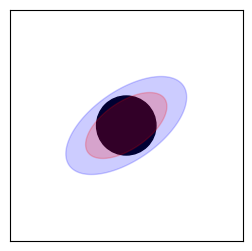

In [105]:
fig, ax = plot_planet(System)

Once loaded you have to update all properties:

In [106]:
System.updateSystem()
print(f"Apparent ring inclination: {System.ieff*RAD:.2f} degrees")
print(f"Apparent ring rotation angle: {System.teff*RAD:.2f} degrees")

Apparent ring inclination: 60.00 degrees
Apparent ring rotation angle: 35.26 degrees


Calculate the PR effect:

In [107]:
System.calculate_PR()
print(f"rho_obs: {System.rho_obs}, rho_true: {System.rho_true}, PR: {System.PR}")

rho_obs: 875.710314641652, rho_true: 1405.9832100913275, PR: -0.2056196693571059


Check what happen if you change some properties:

Apparent ring inclination: 0.00 degrees
Apparent ring rotation angle: -0.00 degrees
rho_obs: 870.344583960288, rho_true: 1405.9832100913275, PR: -0.20828890337004907


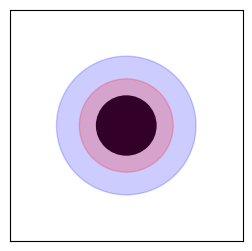

In [108]:
# Face-on ring
System.ir = 90.0*DEG
System.phir = 0.0*DEG
System.updateSystem()
System.calculate_PR()
print(f"Apparent ring inclination: {System.ieff*RAD:.2f} degrees")
print(f"Apparent ring rotation angle: {System.teff*RAD:.2f} degrees")
print(f"rho_obs: {System.rho_obs}, rho_true: {System.rho_true}, PR: {System.PR}")
fig, ax = plot_planet(System)

## PhotoRing as a function of angles:

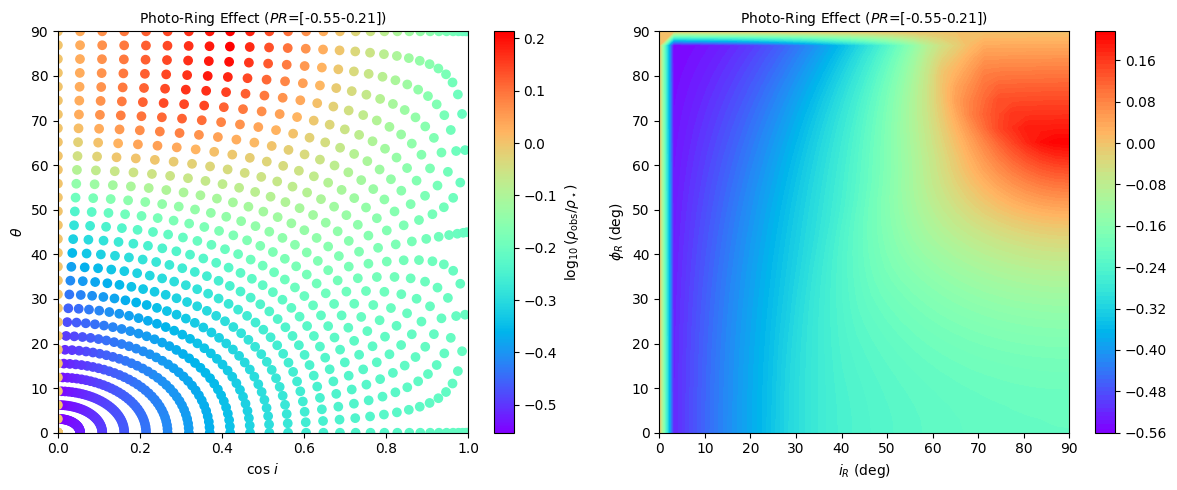

In [109]:
S = RingedSystem()
N1 = 30
N2 = 30

irs = np.linspace(0,90,N1)*DEG
phirs = np.linspace(0,90,N2)*DEG
IR,PHIR = np.meshgrid(irs,phirs)

cieffs = []
teffs = []
PRs = []
ROBs = []
PRcs = np.zeros((N2,N1))
ROBcs = np.zeros((N2,N1))
for i,ir in enumerate(irs):
    S.ir = ir
    for j,phir in enumerate(phirs):
        S.phir = phir
        
        S.updateSystem()
        S.calculate_PR()

        cieffs.append(np.cos(S.ieff))
        teffs.append(S.teff*RAD)

        PRs.append(S.PR)
        ROBs.append(S.rho_obs)
        PRcs[j,i] = S.PR
        ROBcs[j,i] = S.rho_obs

# PR contours
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot
ax = axs[0]
ax.scatter(cieffs, teffs, c=PRs, cmap='rainbow')
cbar = fig.colorbar(ax.collections[0], ax=ax)
ax.set_title(rf"Photo-Ring Effect ($PR$=[{min(PRs):.2f}-{max(PRs):.2f}])", position=(0.5, 1.02), fontsize=10)
ax.set_xlabel(r"$\cos\,i$")
ax.set_ylabel(r"$\theta$")
cbar.ax.set_ylabel(r"$\log_{10}(\rho_{\rm obs}/\rho_\star)$")
ax.margins(0)

# Second subplot
ax = axs[1]
ax.set_title(rf"Photo-Ring Effect ($PR$=[{min(PRs):.2f}-{max(PRs):.2f}])", position=(0.5, 1.02), fontsize=10)
c = ax.contourf(IR * RAD, PHIR * RAD, PRcs, levels=100, cmap='rainbow')
cbar = fig.colorbar(c, ax=ax)
ax.set_xlabel(r"$i_R$ (deg)")
ax.set_ylabel(r"$\phi_R$ (deg)")

plt.tight_layout()
plt.show()

## Kepler-51b

Now build a realistic system:

rho_obs: 1419.1752447167496, rho_true: 2309.8505395597012, PR: -0.21154785251471914
Apparent ring inclination: 72.81 degrees


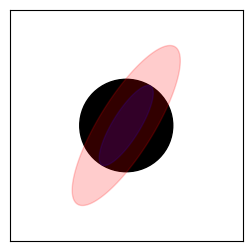

In [110]:
# ============================
# PLANET PROPERTIES
# ============================
Rp_mean = 0.609*RJUP # Masuda et al. 2024
Ms_mean = 0.81*MSUN
Rs_mean = 0.79*RSUN
Porb_mean = 45.15405*DAY # Masuda et al. 2024
borb_mean = 0.0740 # Masuda et al. 2024
Mp_mean = 0.011*MJUP
ap_mean = ((GCONST * Ms_mean * Porb_mean**2) / (4 * pi**2))**(1/3)
iorb_mean = np.arccos(borb_mean*Rs_mean/ap_mean)*RAD

# Minimum planet radius
Rp_min = REARTH*(Mp_mean/MEARTH)**(1/3)
fRp_min = Rp_min/Rp_mean

# ============================
# SYSTEM
# ============================
System = RingedSystem(
    system = dict(
        Mstar=Ms_mean,
        Rstar=Rs_mean,
        Rplanet=Rp_mean, # Libby-Roberts et al. 2020
        Mplanet=Mp_mean, # Libby-Roberts et al. 2020
        ap=ap_mean, #Semi-major axis # Libby-Roberts et al. 2020
        iorb=iorb_mean*DEG, #Orbital inclination
        fe=1, #Exterior ring (Rp)
        fi=2, #Interior ring (Rp)
        ir=60.0*DEG, #Ring inclination
        phir=70.0*DEG, #Ring roll angle
        tau=1.0, #Opacity
    )
)

# Update system
System.updateSystem()
System.calculate_PR()

# Output properties
print(f"rho_obs: {System.rho_obs}, rho_true: {System.rho_true}, PR: {System.PR}")

# Apparent ring inclination 
print(f"Apparent ring inclination: {System.ieff*RAD:.2f} degrees")
fig, ax = plot_planet(System, frac=0.2)